In [1]:
# Import the required libraries

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.ticker as mtick
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from imblearn.combine import SMOTEENN
from sklearn.decomposition import PCA

In [2]:

# GitHub raw file URL
path = r"/content/Telco-Customer-Churn.csv"

# Read CSV file
telco_base_data = pd.read_csv(path)

In [3]:
# Display the first five rows
telco_base_data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Dataset Rows & Columns count
num_rows, num_cols = telco_base_data.shape

print("Number of rows:", num_rows)
print("Number of columns:", num_cols)

Number of rows: 7043
Number of columns: 21


In [5]:
# Checking the all features
telco_base_data.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [6]:
# Checking the data types of all the columns
telco_base_data.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [7]:
# Check the descriptive statistics of numeric variables
telco_base_data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


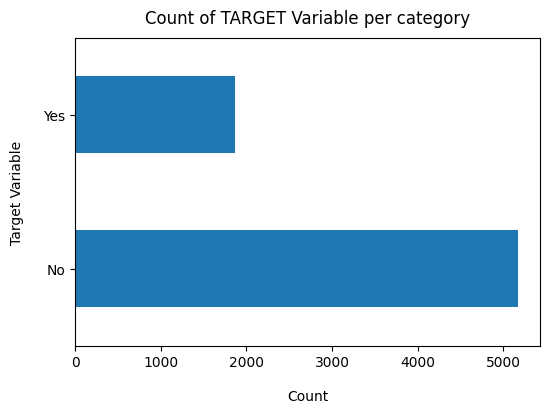

In [8]:
# Plot a horizontal bar chart to display the count of 'Churn' values
telco_base_data['Churn'].value_counts().plot(kind='barh', figsize=(6, 4))
plt.xlabel("Count", labelpad=14)  # Set label for the x-axis
plt.ylabel("Target Variable", labelpad=14)  # Set label for the y-axis
plt.title("Count of TARGET Variable per category", y=1.02)  # Set the title of the plot
plt.show()  # Display the plot

In [9]:
# Calculate the percentage of each 'Churn' category
100 * telco_base_data['Churn'].value_counts() / len(telco_base_data['Churn'])

,count
Churn,
No,73.463013
Yes,26.536987


In [10]:
# Output the count of each category in the 'Churn' column
telco_base_data['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [11]:
# Concise Summary of the dataframe
telco_base_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


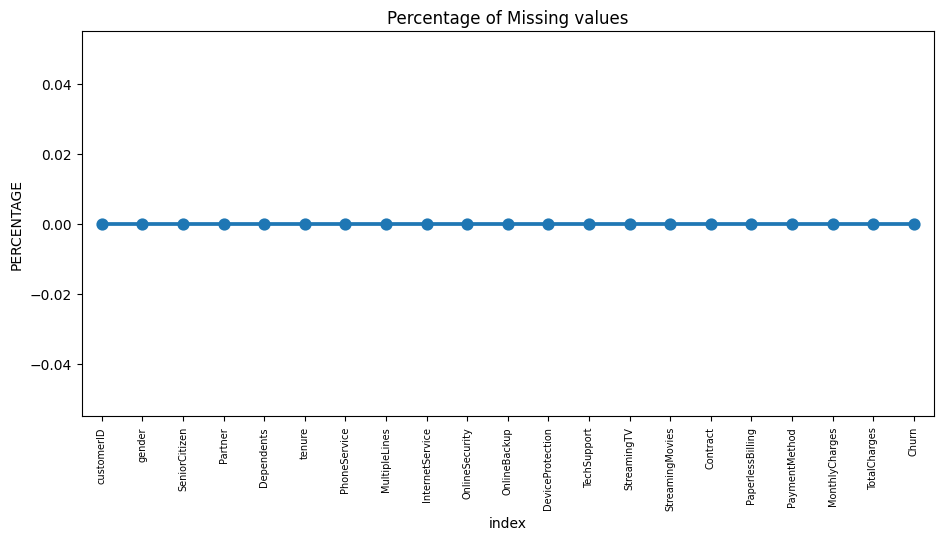

In [12]:
# Create a DataFrame to calculate the percentage of missing values
missing = pd.DataFrame((telco_base_data.isnull().sum()) * 100 / telco_base_data.shape[0]).reset_index()

# Set the figure size for the plot
plt.figure(figsize=(11, 5))

# Create a point plot to visualize the percentage of missing values
ax = sns.pointplot(x='index', y=0, data=missing)

# Rotate x-axis labels and set font size
plt.xticks(rotation=90, fontsize=7)

# Set the title of the plot
plt.title("Percentage of Missing values")

# Set the label for the y-axis
plt.ylabel("PERCENTAGE")

# Display the plot
plt.show()

In [13]:
# Create a copy of the telco_base_data DataFrame
telco_data = telco_base_data.copy()

In [14]:
# Convert the 'TotalCharges' column to numeric, coercing errors
telco_data.TotalCharges = pd.to_numeric(telco_data.TotalCharges, errors='coerce')

# Output the count of missing values in each column
telco_data.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [15]:
# Locate rows where the 'TotalCharges' column is null
telco_data.loc[telco_data['TotalCharges'].isnull() == True]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [16]:
# Removing missing values
telco_data.dropna(how = 'any', inplace = True)

In [17]:
# Get the max tenure
print(telco_data['tenure'].max()) #72

72


In [18]:
# Group the tenure in bins of 12 months
labels = ["{0} - {1}".format(i, i + 11) for i in range(1, 72, 12)]

telco_data['tenure_group'] = pd.cut(telco_data.tenure, range(1, 80, 12), right=False, labels=labels)

In [19]:
telco_data['tenure_group'].value_counts()

,count
tenure_group,
1 - 12,2175
61 - 72,1407
13 - 24,1024
25 - 36,832
49 - 60,832
37 - 48,762


In [20]:
# Drop column customerID and tenure
telco_data.drop(columns= ['customerID','tenure'], axis=1, inplace=True)
telco_data.head()

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
0,Female,0,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,1 - 12
1,Male,0,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,25 - 36
2,Male,0,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1 - 12
3,Male,0,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,37 - 48
4,Female,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1 - 12


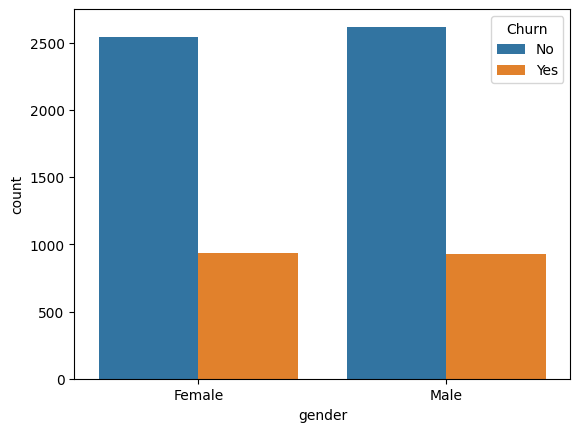

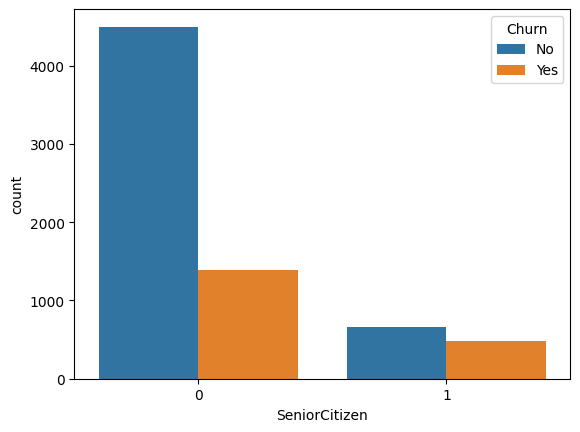

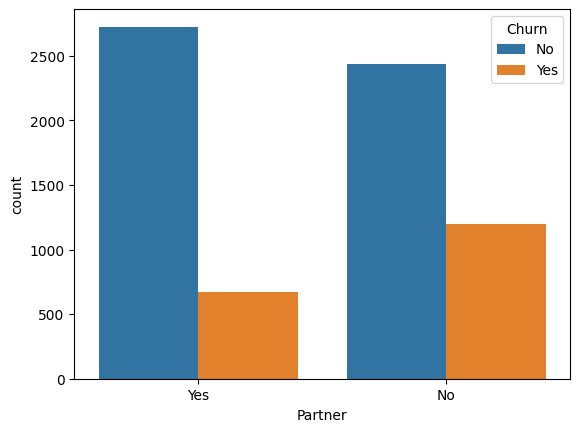

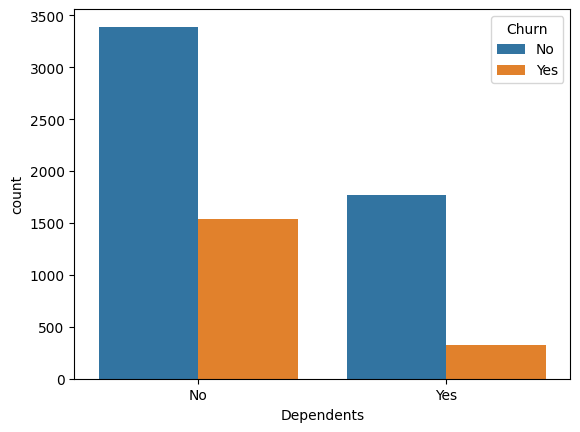

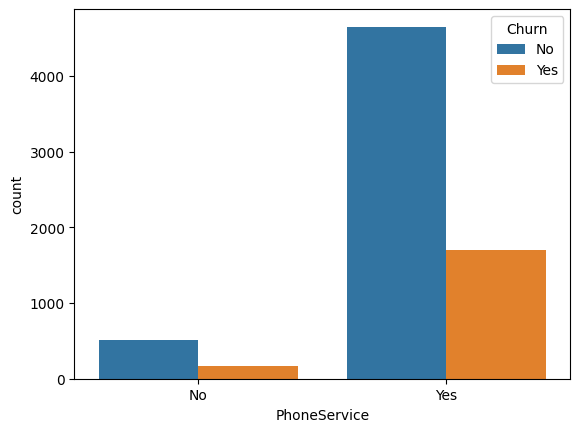

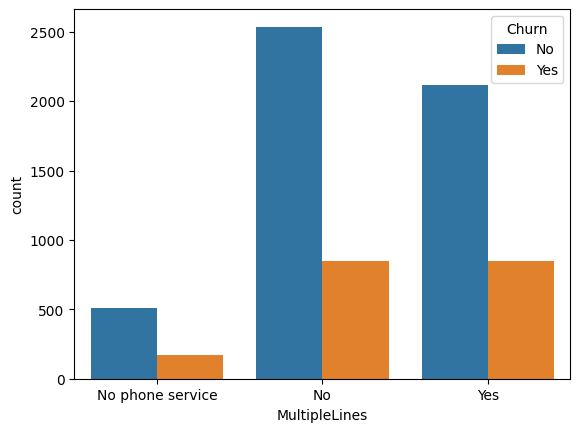

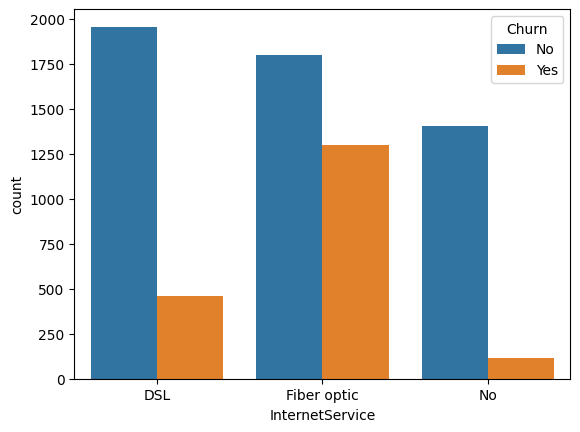

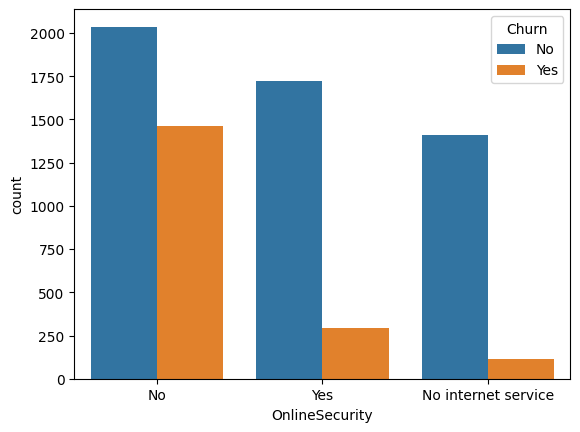

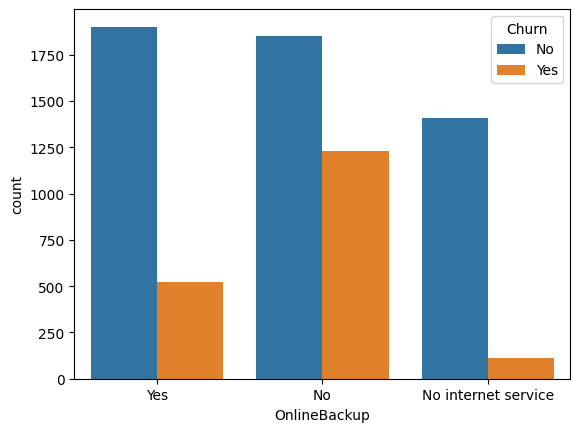

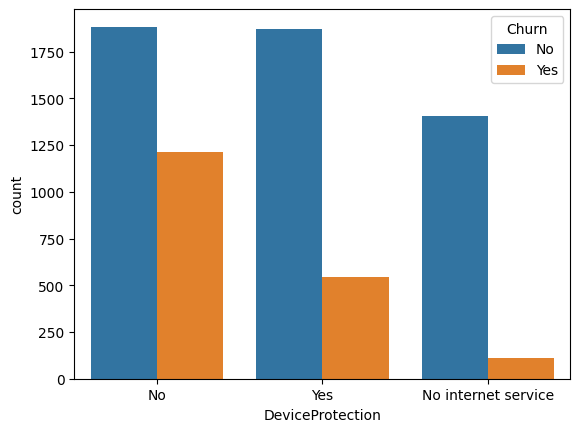

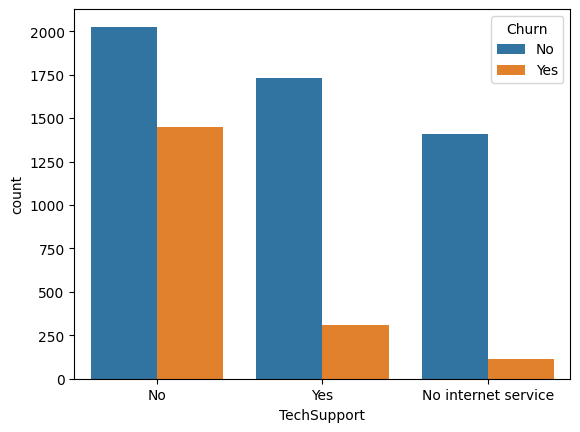

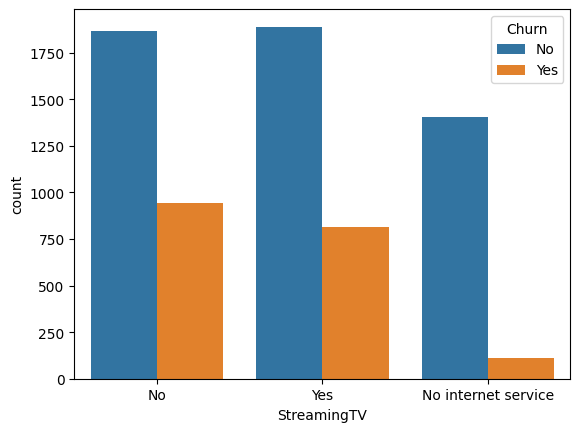

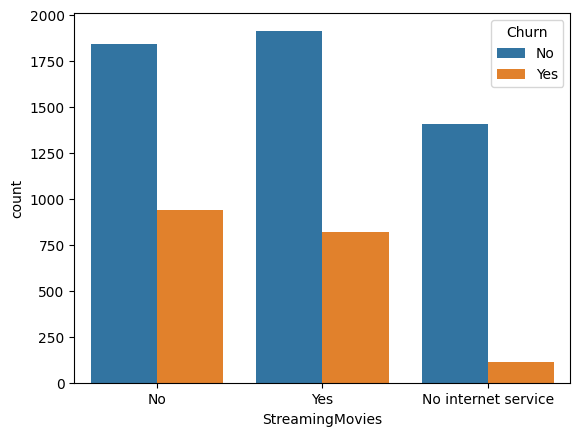

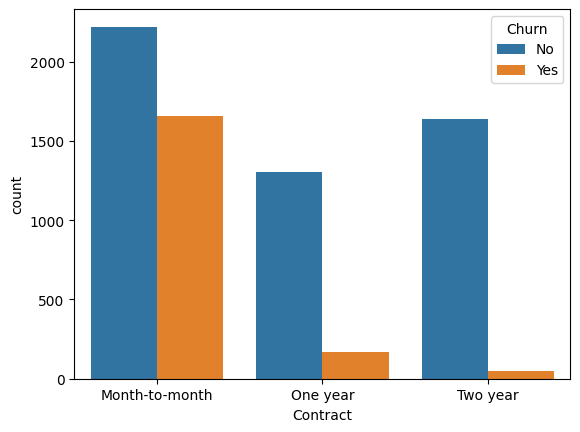

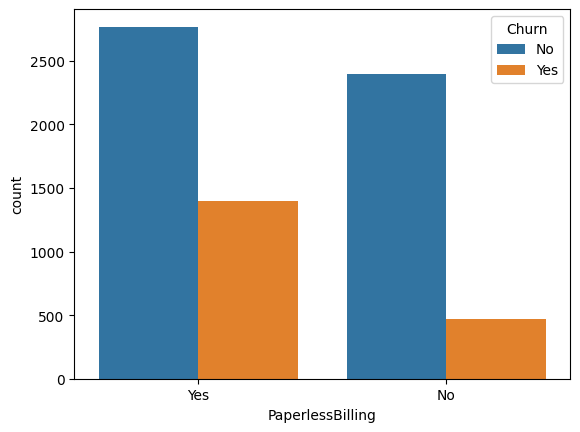

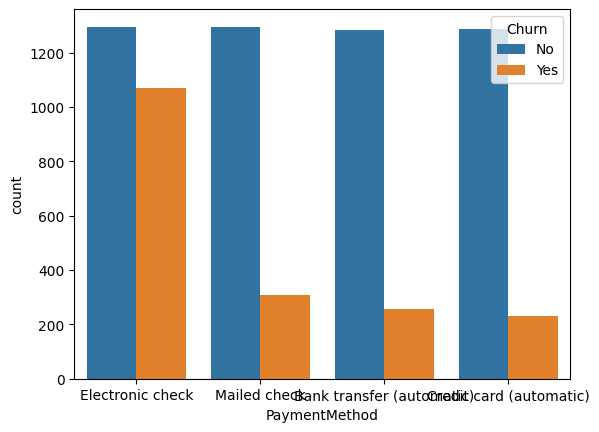

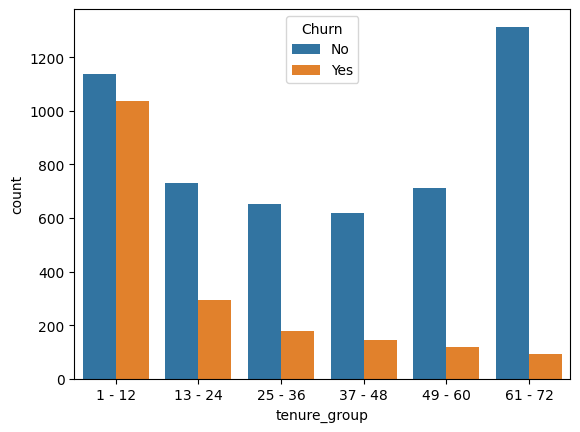

In [21]:
# Iterate through predictors and create count plots for each
for i, predictor in enumerate(telco_data.drop(columns=['Churn', 'TotalCharges', 'MonthlyCharges'])):
    plt.figure(i)  # Create a new figure
    sns.countplot(data=telco_data, x=predictor, hue='Churn')  # Create a count plot for the predictor with respect to 'Churn'

In [22]:
telco_data['Churn'] = np.where(telco_data.Churn == 'Yes',1,0)

In [23]:
telco_data.head()

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
0,Female,0,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,1 - 12
1,Male,0,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0,25 - 36
2,Male,0,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,1 - 12
3,Male,0,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,37 - 48
4,Female,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,1 - 12


In [24]:
# Create dummy variables for categorical columns in telco_data and convert to integer type
telco_data_dummies = pd.get_dummies(telco_data).astype(int)

# Display the first few rows of the modified DataFrame
telco_data_dummies.head()

,SeniorCitizen,MonthlyCharges,TotalCharges,Churn,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,...,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_1 - 12,tenure_group_13 - 24,tenure_group_25 - 36,tenure_group_37 - 48,tenure_group_49 - 60,tenure_group_61 - 72
0,0,29,29,0,1,0,0,1,1,0,...,0,0,1,0,1,0,0,0,0,0
1,0,56,1889,0,0,1,1,0,1,0,...,0,0,0,1,0,0,1,0,0,0
2,0,53,108,1,0,1,1,0,1,0,...,0,0,0,1,1,0,0,0,0,0
3,0,42,1840,0,0,1,1,0,1,0,...,1,0,0,0,0,0,0,1,0,0
4,0,70,151,1,1,0,1,0,1,0,...,0,0,1,0,1,0,0,0,0,0


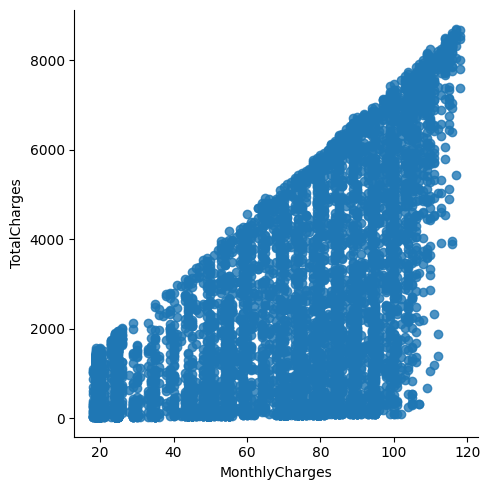

In [25]:
# Create a scatter plot using seaborn to visualize the relationship between 'MonthlyCharges' and 'TotalCharges'
sns.lmplot(data=telco_data_dummies, x='MonthlyCharges', y='TotalCharges', fit_reg=False)
plt.show()  # Display the plot

/tmp/ipykernel_3535/4244006514.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  Mth = sns.kdeplot(telco_data_dummies.MonthlyCharges[(telco_data_dummies["Churn"] == 0)], color="Red", shade=True)
/tmp/ipykernel_3535/4244006514.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  Mth = sns.kdeplot(telco_data_dummies.MonthlyCharges[(telco_data_dummies["Churn"] == 1)], ax=Mth, color="Blue", shade=True)


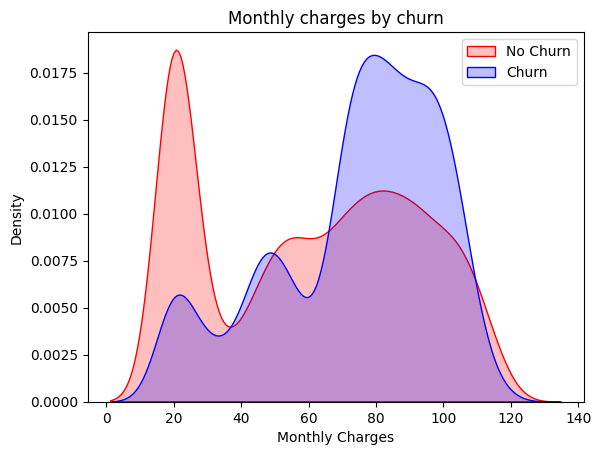

In [26]:
# Create a kernel density plot to compare monthly charges for churned and non-churned customers
Mth = sns.kdeplot(telco_data_dummies.MonthlyCharges[(telco_data_dummies["Churn"] == 0)], color="Red", shade=True)
Mth = sns.kdeplot(telco_data_dummies.MonthlyCharges[(telco_data_dummies["Churn"] == 1)], ax=Mth, color="Blue", shade=True)

# Set legend, y-axis label, x-axis label, and title for the plot
Mth.legend(["No Churn", "Churn"], loc='upper right')
Mth.set_ylabel('Density')
Mth.set_xlabel('Monthly Charges')
Mth.set_title('Monthly charges by churn')
plt.show()

/tmp/ipykernel_3535/833757092.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  Tot = sns.kdeplot(telco_data_dummies.TotalCharges[(telco_data_dummies["Churn"] == 0)], color="Red", shade=True)
/tmp/ipykernel_3535/833757092.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  Tot = sns.kdeplot(telco_data_dummies.TotalCharges[(telco_data_dummies["Churn"] == 1)], ax=Tot, color="Blue", shade=True)


Text(0.5, 1.0, 'Total charges by churn')

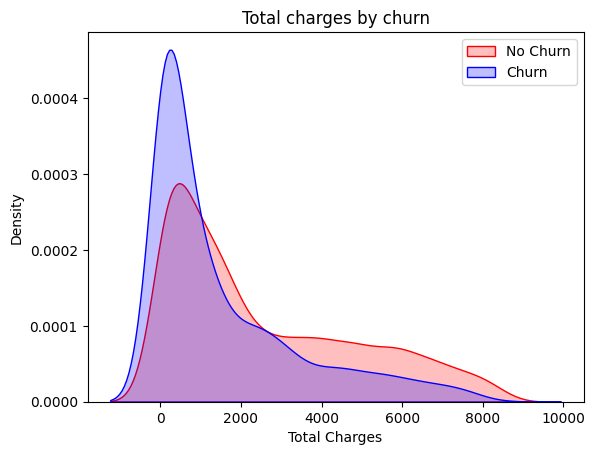

In [27]:
# Create a kernel density plot to compare total charges for churned and non-churned customers
Tot = sns.kdeplot(telco_data_dummies.TotalCharges[(telco_data_dummies["Churn"] == 0)], color="Red", shade=True)
Tot = sns.kdeplot(telco_data_dummies.TotalCharges[(telco_data_dummies["Churn"] == 1)], ax=Tot, color="Blue", shade=True)

# Set legend, y-axis label, x-axis label, and title for the plot
Tot.legend(["No Churn", "Churn"], loc='upper right')
Tot.set_ylabel('Density')
Tot.set_xlabel('Total Charges')
Tot.set_title('Total charges by churn')

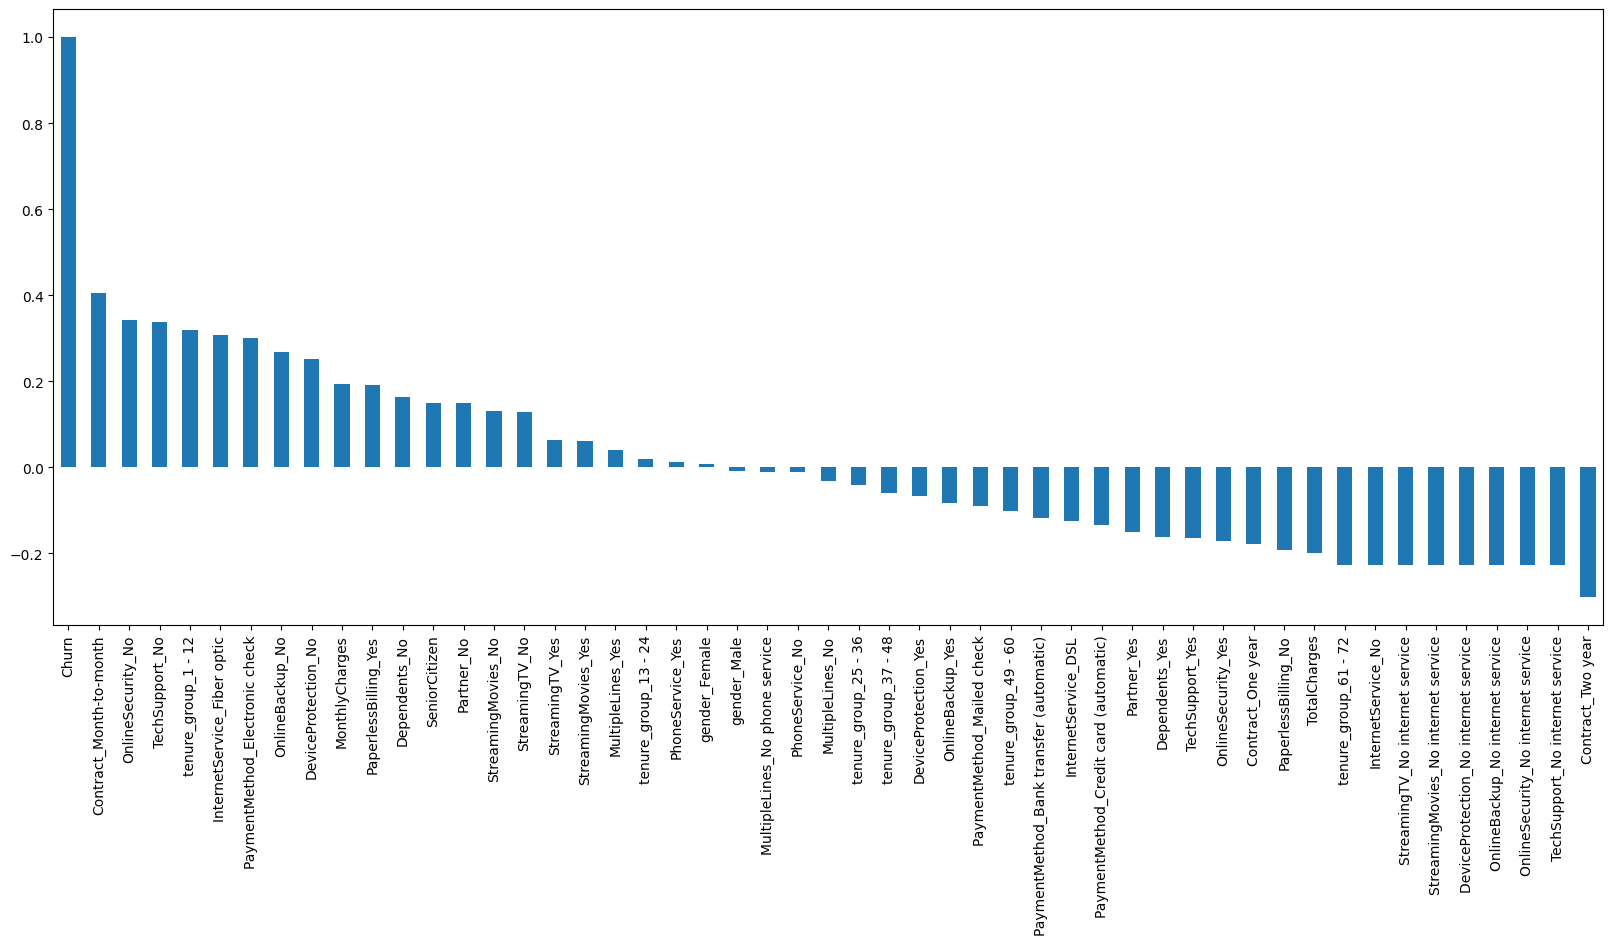

In [28]:
# Set the figure size for the correlation plot
plt.figure(figsize=(20, 8))

# Plot the correlation of each feature with 'Churn' in a bar chart
telco_data_dummies.corr()['Churn'].sort_values(ascending=False).plot(kind='bar')

# Display the plot
plt.show()

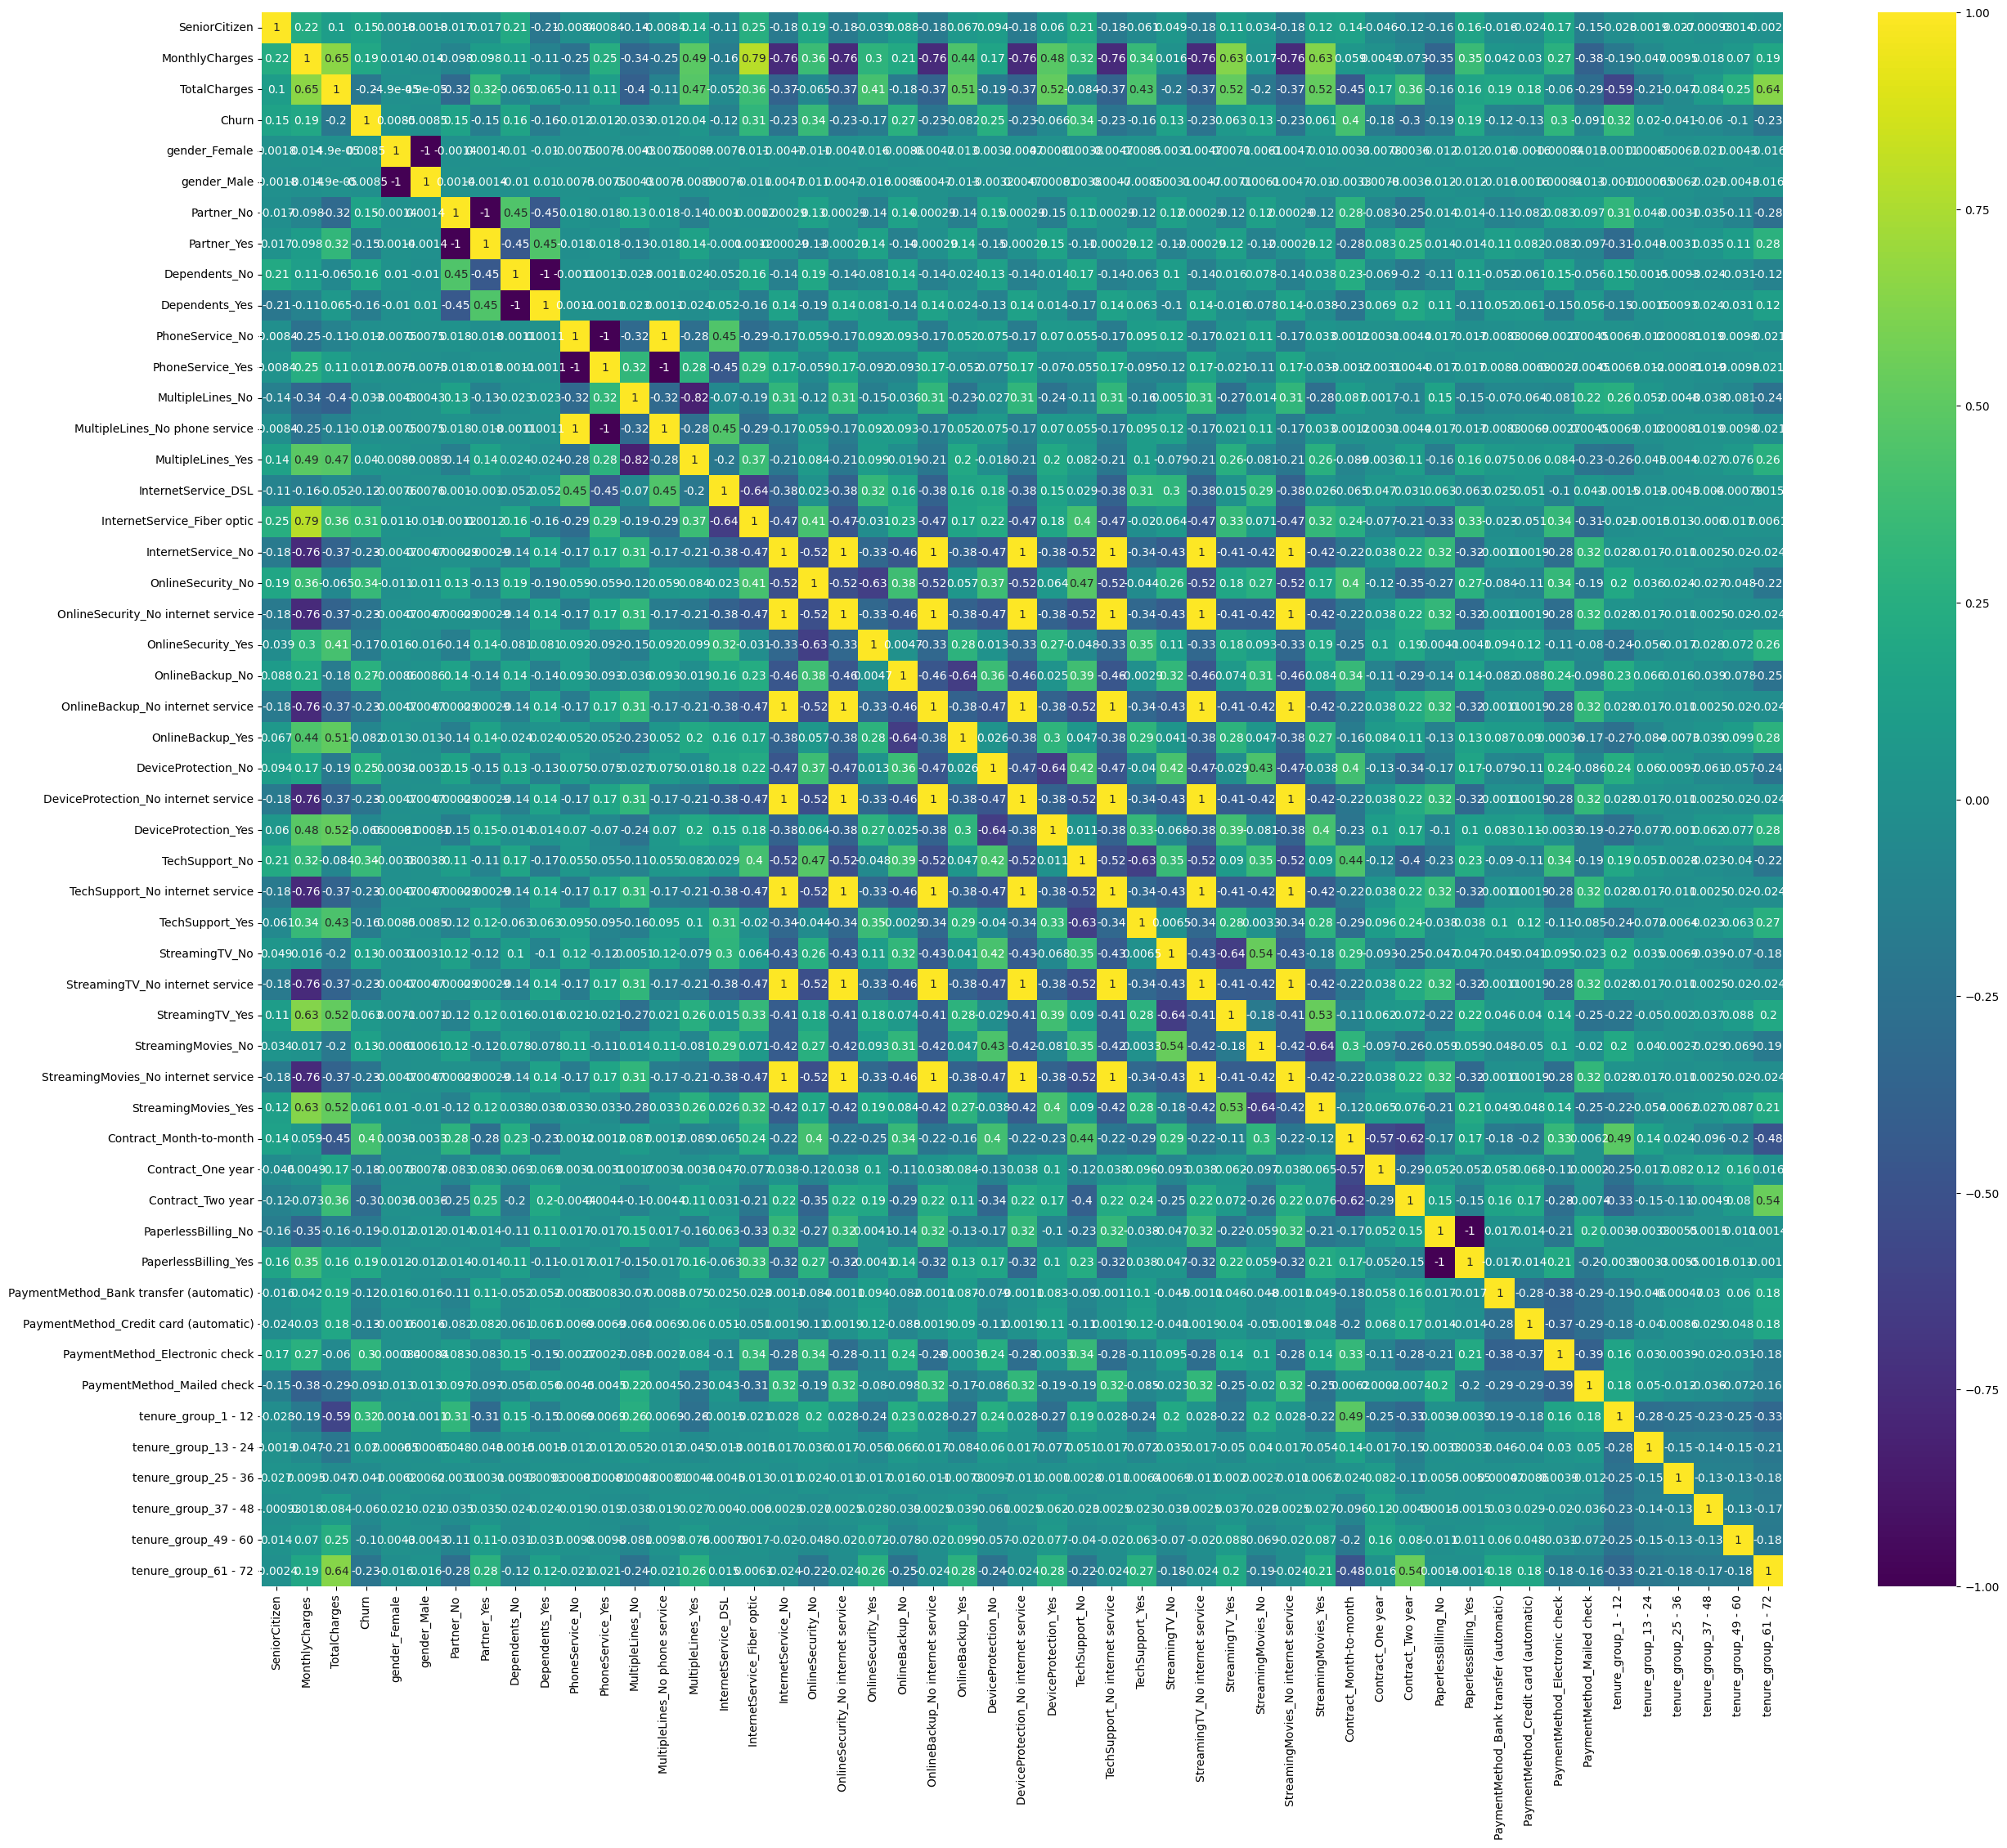

In [29]:
# Set the figure size for the heatmap
plt.figure(figsize=(30, 25))

# Create a heatmap to visualize the correlation matrix of telco_data_dummies
sns.heatmap(telco_data_dummies.corr(), annot=True, cmap="viridis")

# Display the heatmap
plt.show()

In [30]:
# Create a new DataFrame for non-churned and churned customers
new_df1_target0 = telco_data.loc[telco_data["Churn"] == 0]
new_df1_target1 = telco_data.loc[telco_data["Churn"] == 1]

In [31]:
import matplotlib.ticker as ticker

def uniplot(df, col, title, hue=None):
    sns.set_style('whitegrid')  # Set the plot style
    sns.set_context('talk')  # Set the context for the plot
    plt.rcParams["axes.labelsize"] = 20  # Set the label size for the axes
    plt.rcParams['axes.titlesize'] = 22  # Set the title size for the axes
    plt.rcParams['axes.titlepad'] = 30  # Set the title padding for the axes

    temp = pd.Series(data=hue)
    fig, ax = plt.subplots()
    fig.set_size_inches(10, 6)  # Set a smaller size for the plot
    plt.xticks(rotation=45)  # Rotate x-axis labels for better visibility
    plt.title(title)  # Set the title of the plot
    ax = sns.countplot(data=df, x=col, order=df[col].value_counts().index, hue=hue, palette='bright')  # Create a count plot

    plt.yscale('log')  # Set y-axis scale to logarithmic
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))  # Set y-axis formatter
    plt.show()  # Display the plot

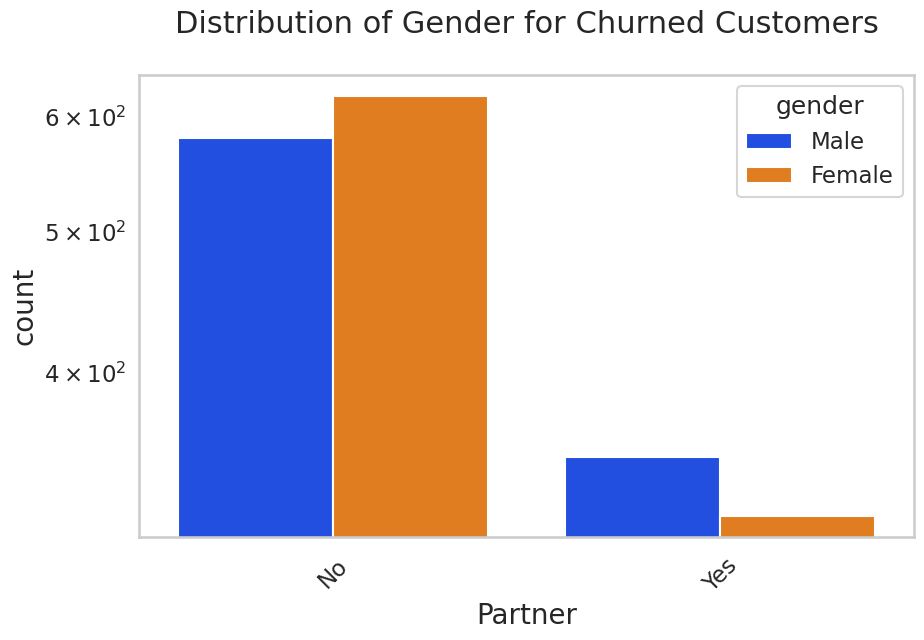

In [32]:
# Create a count plot to visualize the distribution of gender for churned customers based on the 'Partner' column
uniplot(new_df1_target1, col='Partner', title='Distribution of Gender for Churned Customers', hue='gender')

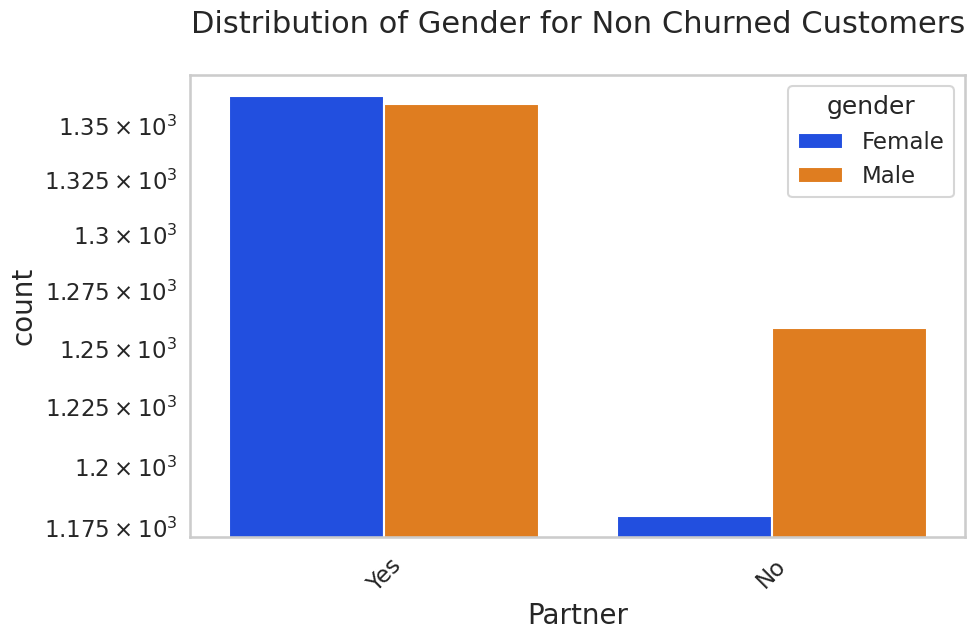

In [33]:
# Create a count plot to visualize the distribution of gender for non-churned customers based on the 'Partner' column
uniplot(new_df1_target0, col='Partner', title='Distribution of Gender for Non Churned Customers', hue='gender')

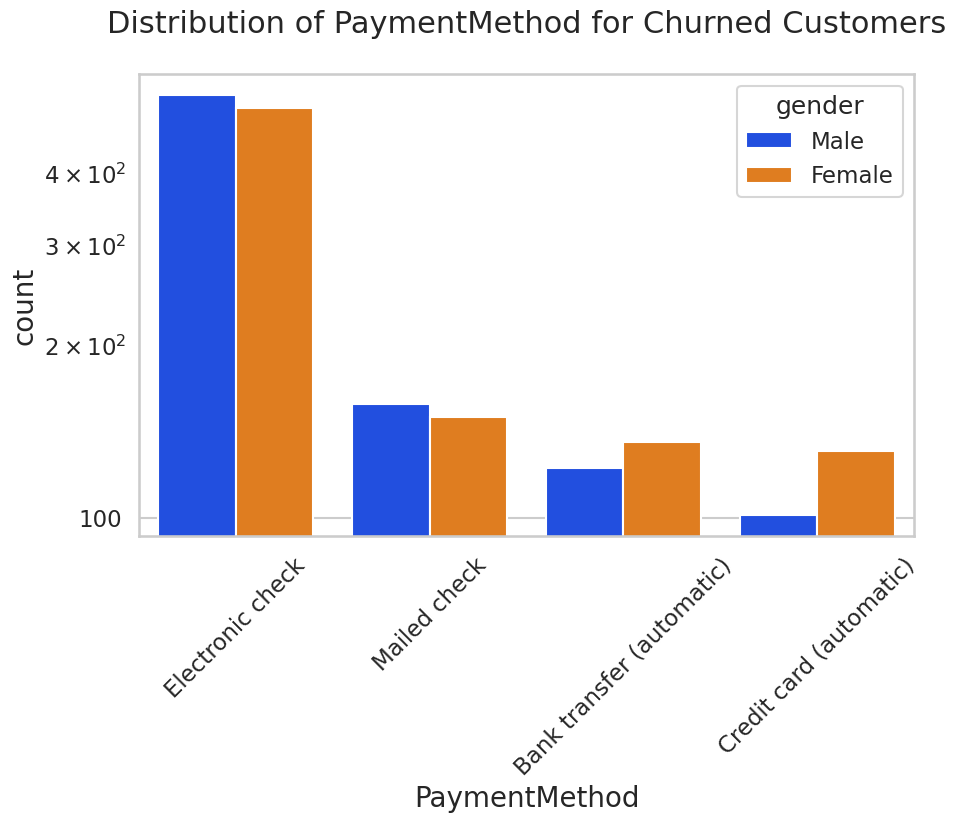

In [34]:
# Create a count plot to visualize the distribution of payment methods for churned customers based on the 'PaymentMethod' column
uniplot(new_df1_target1, col='PaymentMethod', title='Distribution of PaymentMethod for Churned Customers', hue='gender')

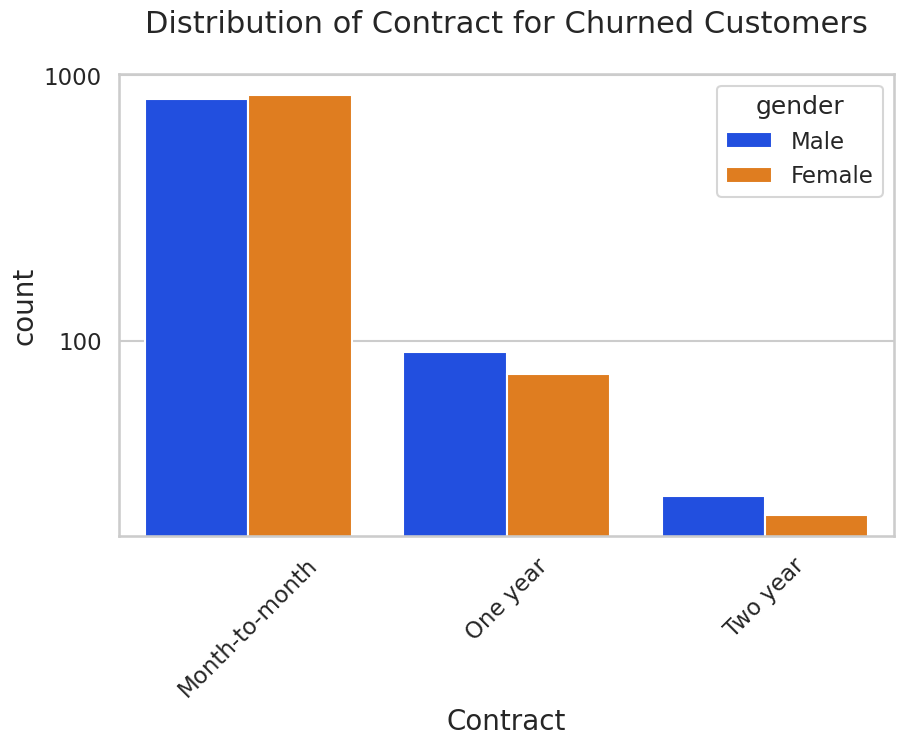

In [35]:
# Create a count plot to visualize the distribution of contract types for churned customers based on the 'Contract' column
uniplot(new_df1_target1, col='Contract', title='Distribution of Contract for Churned Customers', hue='gender')

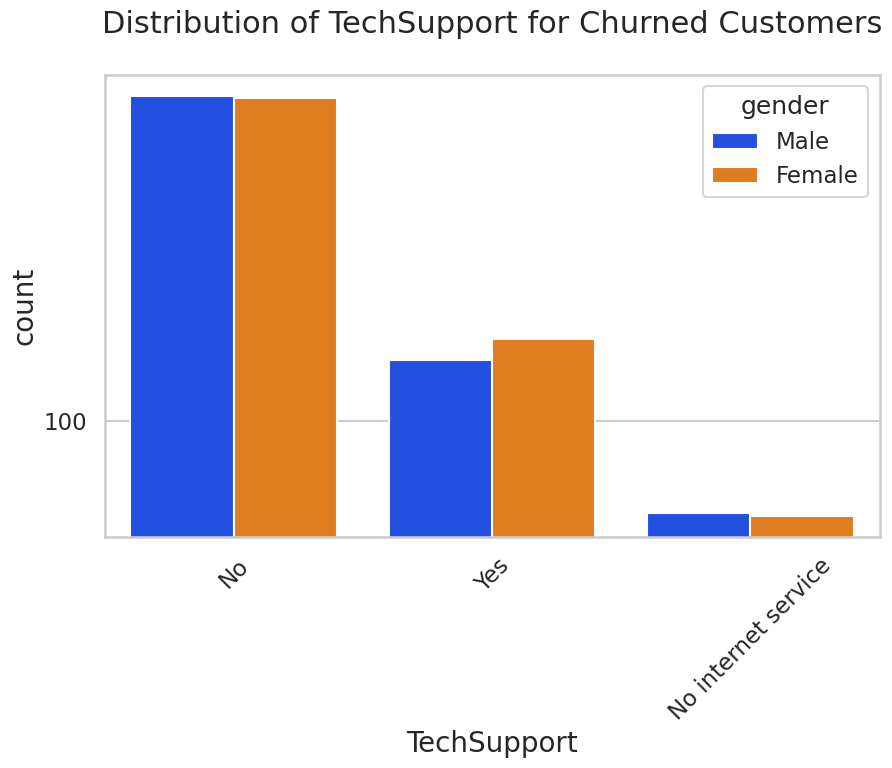

In [36]:
# Create a count plot to visualize the distribution of tech support for churned customers based on the 'TechSupport' column
uniplot(new_df1_target1, col='TechSupport', title='Distribution of TechSupport for Churned Customers', hue='gender')

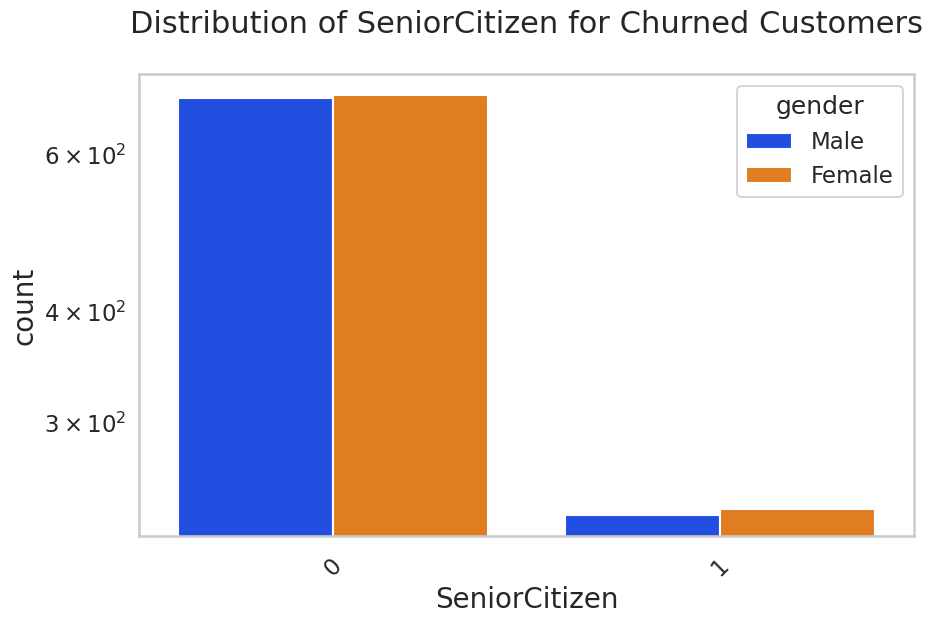

In [37]:
# Create a count plot to visualize the distribution of senior citizens among churned customers based on the 'SeniorCitizen' column
uniplot(new_df1_target1, col='SeniorCitizen', title='Distribution of SeniorCitizen for Churned Customers', hue='gender')

In [38]:
# Copy the dataframe
telco_df = telco_data_dummies.copy()

In [39]:
# Top rows of the dataframe
telco_df.head()

,SeniorCitizen,MonthlyCharges,TotalCharges,Churn,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,...,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_1 - 12,tenure_group_13 - 24,tenure_group_25 - 36,tenure_group_37 - 48,tenure_group_49 - 60,tenure_group_61 - 72
0,0,29,29,0,1,0,0,1,1,0,...,0,0,1,0,1,0,0,0,0,0
1,0,56,1889,0,0,1,1,0,1,0,...,0,0,0,1,0,0,1,0,0,0
2,0,53,108,1,0,1,1,0,1,0,...,0,0,0,1,1,0,0,0,0,0
3,0,42,1840,0,0,1,1,0,1,0,...,1,0,0,0,0,0,0,1,0,0
4,0,70,151,1,1,0,1,0,1,0,...,0,0,1,0,1,0,0,0,0,0


In [40]:
# Assign the features to X and the target variable to y
X = telco_df.drop('Churn', axis=1)
y = telco_df['Churn']

# Output the shape of X and the count of each category in y
print('X:', X.shape)
print('y:', y.value_counts())

X: (7032, 50)
y: Churn
0    5163
1    1869
Name: count, dtype: int64


In [41]:
# Split the data into training and testing sets
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=42)

# Output the shapes of Xtrain and Xtest, and the count of each category in ytrain and ytest
print('Xtrain:', Xtrain.shape)
print('Xtest:', Xtest.shape)
print('ytrain:', ytrain.value_counts())
print('ytest:', ytest.value_counts())

Xtrain: (5625, 50)
Xtest: (1407, 50)
ytrain: Churn
0    4130
1    1495
Name: count, dtype: int64
ytest: Churn
0    1033
1     374
Name: count, dtype: int64


In [42]:
# Create a Decision Tree model with specified parameters
model_dt = DecisionTreeClassifier(criterion="gini", random_state=100, max_depth=6, min_samples_leaf=8)

In [43]:
# Train the Model
model_dt.fit(Xtrain, ytrain)

DecisionTreeClassifier(max_depth=6, min_samples_leaf=8, random_state=100)

In [44]:
# Predict the y value
y_pred = model_dt.predict(Xtest)

In [45]:
# Calculate the accuracy score of the decision tree model using the test data
model_dt.score(Xtest, ytest)

0.7697228144989339

In [46]:
# Print the classification report for the test set using the predicted values and true values, specifying the labels
print(classification_report(ytest, y_pred, labels=[0, 1]))

              precision    recall  f1-score   support

           0       0.84      0.85      0.84      1033
           1       0.57      0.55      0.56       374

    accuracy                           0.77      1407
   macro avg       0.70      0.70      0.70      1407
weighted avg       0.77      0.77      0.77      1407



In [47]:
sm = SMOTEENN()

# Resample the dataset using SMOTEENN to address class imbalance
X_resampled, y_resampled = sm.fit_resample(X, y)

In [48]:
# Split the resampled data into training and testing sets
xr_train, xr_test, yr_train, yr_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

In [49]:
# Create a decision tree classifier with specified parameters
model_dt_smote = DecisionTreeClassifier(criterion="gini", random_state=100, max_depth=6, min_samples_leaf=8)

In [50]:
# Fit the decision tree model to the resampled training data
model_dt_smote.fit(xr_train, yr_train)

# Make predictions using the model
yr_predict = model_dt_smote.predict(xr_test)

# Calculate the accuracy score of the model
model_score_r = model_dt_smote.score(xr_test, yr_test)

# Output the accuracy score and the classification report
print(model_score_r)
print(metrics.classification_report(yr_test, yr_predict))

0.9416884247171453
              precision    recall  f1-score   support

           0       0.95      0.92      0.94       542
           1       0.93      0.96      0.95       607

    accuracy                           0.94      1149
   macro avg       0.94      0.94      0.94      1149
weighted avg       0.94      0.94      0.94      1149



In [51]:
# Output the confusion matrix
print(metrics.confusion_matrix(yr_test, yr_predict))

[[500  42]
 [ 25 582]]


In [52]:
# Create a random forest classifier with specified parameters
model_rf = RandomForestClassifier(n_estimators=100, criterion='gini', random_state=100, max_depth=6, min_samples_leaf=8)

In [53]:
# Train the random forest model
model_rf.fit(Xtrain, ytrain)

RandomForestClassifier(max_depth=6, min_samples_leaf=8, random_state=100)

In [54]:
# Make predictions using the random forest model
y_pred = model_rf.predict(Xtest)

In [55]:
model_rf.score(Xtest, ytest)

0.7846481876332623

In [56]:
print(classification_report(ytest, y_pred, labels=[0,1]))

              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1033
           1       0.64      0.43      0.52       374

    accuracy                           0.78      1407
   macro avg       0.73      0.67      0.69      1407
weighted avg       0.77      0.78      0.77      1407



In [57]:
sm = SMOTEENN()

# Resample the dataset using SMOTEENN to address class imbalance
X_resampled1, y_resampled1 = sm.fit_resample(X, y)

In [58]:
# Split the resampled data into training and testing sets
xr_train1, xr_test1, yr_train1, yr_test1 = train_test_split(X_resampled1, y_resampled1, test_size=0.2, random_state=42)

In [59]:
# Create a random forest classifier with specified parameters
model_rf_smote = RandomForestClassifier(n_estimators=100, criterion='gini', random_state=100, max_depth=6, min_samples_leaf=8)

In [60]:
# Train the random forest model using the resampled training data
model_rf_smote.fit(xr_train1, yr_train1)

RandomForestClassifier(max_depth=6, min_samples_leaf=8, random_state=100)

In [61]:
# Make predictions using the random forest model
yr_predict1 = model_rf_smote.predict(xr_test1)

In [62]:
model_score_r1 = model_rf_smote.score(xr_test1, yr_test1)

In [63]:
# Output the accuracy score and the classification report
print(model_score_r1)
print(metrics.classification_report(yr_test1, yr_predict1))

0.9310938845822567
              precision    recall  f1-score   support

           0       0.95      0.90      0.92       528
           1       0.92      0.96      0.94       633

    accuracy                           0.93      1161
   macro avg       0.93      0.93      0.93      1161
weighted avg       0.93      0.93      0.93      1161



In [64]:
# Output the confusion matrix
print(metrics.confusion_matrix(yr_test1, yr_predict1))

[[474  54]
 [ 26 607]]


In [65]:
# Applying PCA
pca = PCA(0.9)
xr_train_pca = pca.fit_transform(xr_train1)
xr_test_pca = pca.transform(xr_test1)
explained_variance = pca.explained_variance_ratio_

In [66]:
# Create a random forest classifier with specified parameters
model = RandomForestClassifier(n_estimators=100, criterion='gini', random_state=100, max_depth=6, min_samples_leaf=8)

In [67]:
# Train the Model
model.fit(xr_train_pca, yr_train1)

RandomForestClassifier(max_depth=6, min_samples_leaf=8, random_state=100)

In [68]:
yr_predict_pca = model.predict(xr_test_pca)

In [69]:
# Calculate the accuracy score of the model using the test data
model_score_r_pca = model.score(xr_test_pca, yr_test1)

# Output the accuracy score and the classification report
print(model_score_r_pca)
print(metrics.classification_report(yr_test1, yr_predict_pca))

0.7260981912144703
              precision    recall  f1-score   support

           0       0.67      0.79      0.72       528
           1       0.79      0.68      0.73       633

    accuracy                           0.73      1161
   macro avg       0.73      0.73      0.73      1161
weighted avg       0.74      0.73      0.73      1161



In [70]:
import pickle

In [71]:
filename = 'model.sav'

In [72]:
# Save the model to a file using pickle
pickle.dump(model_rf_smote, open(filename, 'wb'))

In [73]:
# Load the model from the file using pickle
load_model = pickle.load(open(filename, 'rb'))

In [74]:
model_score_r1 = load_model.score(xr_test1, yr_test1)

In [75]:
model_score_r1

0.9310938845822567